# Report preprocessing and weak-label generation

This notebook converts the multilingual radiology reports into **auditable weak supervision** for the twelve competition targets. It covers three preprocessing stages:

1. normalize and structure report text;
2. validate an assertion-aware label extractor against the manually labeled studies;
3. generate probabilistic weak labels and confidence weights for otherwise unlabeled studies.

This is a conservative baseline, not a substitute for clinical annotation. A finding can be **positive**, **negative**, **uncertain**, or **unmentioned**. Unmentioned findings are never automatically converted to negative labels.

## Outputs

- `normalized_reports.csv` — normalized report text and text metadata;
- `weak_labels.csv` — assertion states, probabilities, confidence weights, and provenance;
- `weak_label_validation.csv` — per-target extractor metrics on verified labels.

In [1]:
from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid")

ID_COL = "StudyInstanceUID"
LABEL_COLS = [
    "ACL", "MCL", "Medial Meniscus", "Lateral Meniscus",
    "Medial OA", "Lateral OA", "PF OA", "Effusion",
    "Synovitis", "Baker's", "Contusion", "Fracture",
]
SEED = 42

## 1. Locate and load the competition table

In [2]:
def find_data_dir():
    candidates = [
        Path("/kaggle/input/competitions/rsna-knee-abnormality-detection"),
        Path("/kaggle/input/rsna-knee-abnormality-detection"),
        Path("/kaggle/input/rsna-knee-abnormalities-detection"),
        Path("../input/rsna-knee-abnormality-detection"),
        Path("data"), Path("input"), Path("."),
    ]
    for path in candidates:
        if (path / "train.csv").exists():
            return path.resolve()
    root = Path("/kaggle/input")
    if root.exists():
        matches = [p.parent for p in root.rglob("train.csv") if "StudyInstanceUID" in pd.read_csv(p, nrows=1).columns]
        if matches:
            return matches[0].resolve()
        mounted = "\n  - ".join(sorted(p.name for p in root.iterdir())) or "(none)"
        raise FileNotFoundError(
            "Competition data was not found. In Kaggle select Add Input → Competitions → "
            "RSNA Knee Abnormalities Detection, then restart the session.\n"
            f"Mounted inputs:\n  - {mounted}"
        )
    raise FileNotFoundError("Set DATA_DIR to the local directory containing train.csv.")

DATA_DIR = find_data_dir()
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA_DIR / "train.csv")
required = {ID_COL, "Report", *LABEL_COLS}
missing = required - set(train.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"
assert train[ID_COL].is_unique
print(f"Data: {DATA_DIR}")
print(f"Studies: {len(train):,}; fully labeled: {train[LABEL_COLS].notna().all(axis=1).sum():,}")
display(train[[ID_COL, "Report", *LABEL_COLS]].head(2))

Data: /kaggle/input/competitions/rsna-knee-abnormality-detection
Studies: 4,407; fully labeled: 58


,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,Técnica: RMN de la rodilla. Resultados: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cóndilo femoral medial. Artrosis femorotibia...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027199792075652399585,[DATE]: * MR Knie Rechts 15ch AA Klinische Inlichtingen: [DATE]. Diagnostische vraagstellling: Meniscusscheur/mediaal? Scanprotocol (DRB) : sag intermediair...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Normalize report text

Normalization preserves clinically meaningful punctuation and negation while standardizing Unicode, whitespace, and common formatting artifacts. The original report is retained in `train`; extraction uses `ReportNormalized`.

In [3]:
def normalize_report(text):
    if pd.isna(text):
        return ""
    text = unicodedata.normalize("NFKC", str(text))
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"\[(?:DATE|TIME|AGE|NAME|ID)\]", " ", text, flags=re.I)
    text = text.replace("–", "-").replace("—", "-")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r" *\n+ *", "\n", text)
    return text.strip().lower()

normalized = pd.DataFrame({
    ID_COL: train[ID_COL],
    "ReportNormalized": train["Report"].map(normalize_report),
})
normalized["ReportCharacters"] = normalized["ReportNormalized"].str.len()
normalized["ReportWords"] = normalized["ReportNormalized"].str.findall(r"\b\w+\b").str.len()
normalized["HasCyrillic"] = normalized["ReportNormalized"].str.contains(r"[\u0400-\u04ff]", regex=True)
normalized["HasLatin"] = normalized["ReportNormalized"].str.contains(r"[a-z]", regex=True)
normalized.to_csv(OUTPUT_DIR / "normalized_reports.csv", index=False)
display(normalized.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
StudyInstanceUID,4407,4407,1.2.826.0.1.3680043.8.498.99957611207313098696146908027229590966,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ReportNormalized,4407,4261,diz eklemi içi sıvı miktarı normal. çapraz ve yan bağlar normal. medyal ve lateral menisküs normal. eklem kıkırdakları ve kemikler normal. ekstensör mekaniz...,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ReportCharacters,4407.0,NaN,NaN,NaN,1087.519855,684.717684,52.0,584.0,970.0,1444.0,4630.0
ReportWords,4407.0,NaN,NaN,NaN,148.730429,96.74218,7.0,76.0,129.0,202.0,685.0
HasCyrillic,4407,2,False,4187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HasLatin,4407,2,True,4298,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Assertion-aware clinical phrase extractor

The dictionaries cover common English, Spanish, German, Dutch, French, Portuguese, and Russian expressions found in knee reports. They should be expanded after reviewing false positives and false negatives.

Each mention is evaluated within its sentence and a local prefix window. The extractor prioritizes uncertainty, then negation, then positive assertion. Conflicting assertions yield `uncertain` rather than a forced label.

In [4]:
TARGET_PATTERNS = {
    "ACL": [r"\bacl\b", r"anterior cruciate ligament", r"ligamento cruzado anterior", r"ligament croisé antérieur", r"vorder(?:e|en) kreuzband", r"voorste kruisband", r"передн\w+ крестообразн\w+ связ"],
    "MCL": [r"\bmcl\b", r"medial collateral ligament", r"ligamento colateral medial", r"ligament collatéral médial", r"innenband", r"mediale collaterale band", r"медиальн\w+ коллатеральн\w+ связ"],
    "Medial Meniscus": [r"medial menisc\w*", r"menisc\w+ medial", r"menisco (?:interno|medial)", r"ménisque médial", r"innenmeniskus", r"mediale meniscus", r"медиальн\w+ мениск"],
    "Lateral Meniscus": [r"lateral menisc\w*", r"menisc\w+ lateral", r"menisco (?:externo|lateral)", r"ménisque latéral", r"außenmeniskus", r"laterale meniscus", r"латеральн\w+ мениск"],
    "Medial OA": [r"medial.{0,40}(?:osteoarthr\w*|arthrosis|degenerat\w*|chondrosis)", r"(?:osteoarthr\w*|arthrosis).{0,40}medial", r"artrosis.{0,30}medial"],
    "Lateral OA": [r"lateral.{0,40}(?:osteoarthr\w*|arthrosis|degenerat\w*|chondrosis)", r"(?:osteoarthr\w*|arthrosis).{0,40}lateral", r"artrosis.{0,30}lateral"],
    "PF OA": [r"patellofemoral.{0,40}(?:osteoarthr\w*|arthrosis|degenerat\w*|chondr\w*)", r"(?:osteoarthr\w*|arthrosis).{0,40}patellofemoral", r"femoropatel\w+.{0,40}(?:artrosis|condropat\w*)"],
    "Effusion": [r"\beffusion\b", r"joint fluid", r"derrame (?:articular|intraarticular)", r"épanchement", r"gelenkerguss", r"gewrichtsvocht", r"выпот"],
    "Synovitis": [r"synovitis", r"sinovitis", r"synovit\w*", r"синовит"],
    "Baker's": [r"baker'?s? cyst", r"popliteal cyst", r"quiste de baker", r"kyste de baker", r"baker[- ]zyste", r"bakerse cyste", r"кист\w+ бейкер"],
    "Contusion": [r"bone (?:contusion|bruise)", r"osseous contusion", r"contusi[oó]n [oó]sea", r"bone marrow edema", r"œdème osseux", r"knochenkontusion", r"костн\w+ ушиб"],
    "Fracture": [r"fractur\w*", r"fraktur\w*", r"fractura", r"breuk", r"перелом"],
}

NEGATION = [
    r"\bno\b", r"\bnot\b", r"without", r"negative for", r"intact", r"normal",
    r"sin evidencia de", r"no (?:hay|se observa|se identifica)", r"ausencia de",
    r"kein(?:e|en|er)?", r"ohne", r"niet", r"geen", r"sans", r"pas de", r"не выявлено", r"нет",
]
UNCERTAINTY = [
    r"possible", r"possibly", r"probable", r"may represent", r"cannot exclude", r"suspicious",
    r"posible", r"probable", r"podr[ií]a", r"verdacht", r"mogelijk", r"peut[- ]être", r"возможн",
]

NEG_RE = re.compile("|".join(f"(?:{p})" for p in NEGATION), re.I)
UNCERTAIN_RE = re.compile("|".join(f"(?:{p})" for p in UNCERTAINTY), re.I)
COMPILED_TARGETS = {label: re.compile("|".join(f"(?:{p})" for p in patterns), re.I) for label, patterns in TARGET_PATTERNS.items()}

def sentence_spans(text):
    return [s.strip() for s in re.split(r"(?<=[.!?;])\s+|\n+", text) if s.strip()]

def classify_mention(sentence, match):
    prefix = sentence[max(0, match.start() - 80):match.start()]
    scope = prefix + match.group(0)
    if UNCERTAIN_RE.search(scope):
        return "uncertain"
    if NEG_RE.search(scope):
        return "negative"
    return "positive"

def extract_target(text, target):
    assertions, evidence = [], []
    for sentence in sentence_spans(text):
        for match in COMPILED_TARGETS[target].finditer(sentence):
            assertions.append(classify_mention(sentence, match))
            evidence.append(sentence[:300])
    states = set(assertions)
    if not states:
        state = "unmentioned"
    elif "uncertain" in states or {"positive", "negative"} <= states:
        state = "uncertain"
    elif "positive" in states:
        state = "positive"
    else:
        state = "negative"
    return state, " || ".join(dict.fromkeys(evidence))[:1000]

## 4. Extract assertions and inspect coverage

,negative,positive,uncertain,unmentioned,mentioned_pct
Effusion,752,1458,18,2179,50.56
Lateral Meniscus,482,1499,42,2384,45.90
Medial Meniscus,78,1821,48,2460,44.18
ACL,376,1305,40,2686,39.05
MCL,290,1345,11,2761,37.35
Baker's,488,566,5,3348,24.03
Contusion,460,384,39,3524,20.04
Fracture,549,207,30,3621,17.84
Synovitis,17,397,6,3987,9.53
PF OA,6,285,1,4115,6.63


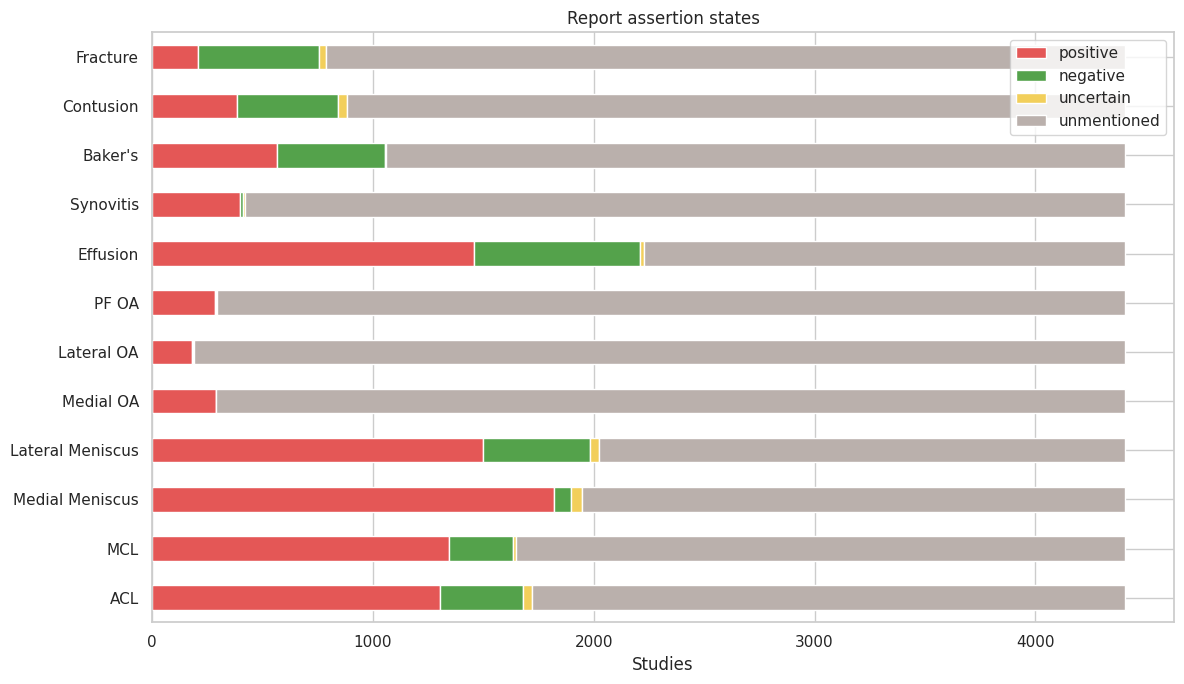

In [5]:
states = pd.DataFrame({ID_COL: train[ID_COL]})
evidence = pd.DataFrame({ID_COL: train[ID_COL]})
for label in LABEL_COLS:
    extracted = normalized["ReportNormalized"].map(lambda text: extract_target(text, label))
    states[f"{label}__state"] = extracted.str[0]
    evidence[f"{label}__evidence"] = extracted.str[1]

coverage = pd.DataFrame({
    label: states[f"{label}__state"].value_counts()
    for label in LABEL_COLS
}).fillna(0).astype(int).T
coverage["mentioned_pct"] = 100 * (1 - coverage.get("unmentioned", 0) / len(states))
display(coverage.sort_values("mentioned_pct", ascending=False).round(2))

plot_data = coverage.reindex(columns=["positive", "negative", "uncertain", "unmentioned"], fill_value=0)
plot_data.plot(kind="barh", stacked=True, figsize=(12, 7), color=["#E45756", "#54A24B", "#F2CF5B", "#BAB0AC"])
plt.title("Report assertion states")
plt.xlabel("Studies")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 5. Validate against verified targets

Validation is performed only where the competition provides a label. Two views are reported:

- **coverage**: fraction of verified examples on which the extractor makes a positive/negative decision;
- **selective performance**: precision, recall, specificity, accuracy, and balanced accuracy among decided examples.

Metrics based on only 58 enriched studies are uncertain. Review the evidence snippets for every error before trusting the generated labels.

In [6]:
def safe_div(num, den):
    return num / den if den else np.nan

validation_rows = []
error_rows = []
for label in LABEL_COLS:
    truth = train[label]
    state = states[f"{label}__state"]
    verified = truth.notna()
    decided = state.isin(["positive", "negative"])
    use = verified & decided
    pred = state.eq("positive")
    y = truth.eq(1)
    tp = int((use & pred & y).sum())
    fp = int((use & pred & ~y).sum())
    tn = int((use & ~pred & ~y).sum())
    fn = int((use & ~pred & y).sum())
    validation_rows.append({
        "label": label, "verified_n": int(verified.sum()), "decided_n": int(use.sum()),
        "coverage": safe_div(use.sum(), verified.sum()), "tp": tp, "fp": fp, "tn": tn, "fn": fn,
        "precision": safe_div(tp, tp + fp), "recall": safe_div(tp, tp + fn),
        "specificity": safe_div(tn, tn + fp), "accuracy": safe_div(tp + tn, use.sum()),
        "balanced_accuracy": np.nanmean([safe_div(tp, tp + fn), safe_div(tn, tn + fp)]),
    })
    wrong = use & pred.ne(y)
    for idx in train.index[wrong]:
        error_rows.append({
            ID_COL: train.at[idx, ID_COL], "label": label, "truth": int(train.at[idx, label]),
            "state": state.at[idx], "evidence": evidence.at[idx, f"{label}__evidence"],
        })

validation = pd.DataFrame(validation_rows).set_index("label")
validation.to_csv(OUTPUT_DIR / "weak_label_validation.csv")
display(validation.round(3))
errors = pd.DataFrame(error_rows)
print(f"Total decided validation errors: {len(errors)}")
display(errors.head(30))

,verified_n,decided_n,coverage,tp,fp,tn,fn,precision,recall,specificity,accuracy,balanced_accuracy
label,,,,,,,,,,,,
ACL,58,31,0.534,14,15,2,0,0.483,1.0,0.118,0.516,0.559
MCL,58,26,0.448,6,16,4,0,0.273,1.0,0.200,0.385,0.600
Medial Meniscus,58,32,0.552,14,17,1,0,0.452,1.0,0.056,0.469,0.528
Lateral Meniscus,58,33,0.569,16,12,5,0,0.571,1.0,0.294,0.636,0.647
Medial OA,58,3,0.052,3,0,0,0,1.000,1.0,NaN,1.000,1.000
Lateral OA,58,3,0.052,1,2,0,0,0.333,1.0,0.000,0.333,0.500
PF OA,58,3,0.052,0,3,0,0,0.000,NaN,0.000,0.000,0.000
Effusion,58,35,0.603,19,11,5,0,0.633,1.0,0.312,0.686,0.656
Synovitis,58,13,0.224,9,4,0,0,0.692,1.0,0.000,0.692,0.500


Total decided validation errors: 89


,StudyInstanceUID,label,truth,state,evidence
0,1.2.826.0.1.3680043.8.498.10170898615867673028696505248839028269,ACL,0,positive,acl is intact.
1,1.2.826.0.1.3680043.8.498.10306159113324811538703788080836752052,ACL,0,positive,anterior cruciate ligament (acl): normal with both bundles intact.
2,1.2.826.0.1.3680043.8.498.11548045715264151632153040089882701935,ACL,0,positive,"in the intercondylar notch, there is interstitial tear of the anterior cruciate ligament, at mid substance. || interstitial tear of the anterior cruciate li..."
3,1.2.826.0.1.3680043.8.498.11771393824519892797114773408583976756,ACL,0,positive,"* interstitial hyperintense signal of acl, in favor of grade 1 injury. || > the contour of acl & pcl appear to be within normal. || suspect grade 1 injury o..."
4,1.2.826.0.1.3680043.8.498.11851412923016044948101698015974810604,ACL,0,positive,anterior cruciate ligament (acl): normal with both bundles intact.
5,1.2.826.0.1.3680043.8.498.11915937982684988073644209606907169581,ACL,0,positive,mild early intraosseous cystic changes at the tibial insertion of the anterior cruciate ligament.
6,1.2.826.0.1.3680043.8.498.13267780356245120052411517053322874891,ACL,0,positive,"> the contour of acl is not all in a straight line but increase signal intensity inside, in favor of grade 2 injury. || grade 2 injury of anterior cruciate ..."
7,1.2.826.0.1.3680043.8.498.16060119389060497136231217718921482192,ACL,0,positive,acl normal.
8,1.2.826.0.1.3680043.8.498.22109739962224309418874538994436903404,ACL,0,positive,anterior cruciate ligament (acl): normal with both bundles intact.
9,1.2.826.0.1.3680043.8.498.27437263843446879932281897446100134924,ACL,0,positive,acl normal.


### Important quality gate

Do not use weak labels blindly. Before image training, manually review the displayed extraction errors and a random sample from each assertion state. Expand dictionaries and scope rules without inspecting test reports. Ideally, use repeated cross-validation or an independently annotated report subset when replacing this rule-based baseline with a learned multilingual extractor.

In [7]:
sample_rows = []
for label in LABEL_COLS:
    for state_name in ["positive", "negative", "uncertain"]:
        candidates = states.index[states[f"{label}__state"].eq(state_name)]
        if len(candidates):
            idx = candidates.to_series().sample(min(2, len(candidates)), random_state=SEED).tolist()
            for i in idx:
                sample_rows.append({
                    ID_COL: train.at[i, ID_COL], "label": label, "state": state_name,
                    "evidence": evidence.at[i, f"{label}__evidence"],
                })
display(pd.DataFrame(sample_rows))

,StudyInstanceUID,label,state,evidence
0,1.2.826.0.1.3680043.8.498.86968600239724310678905311244945464037,ACL,positive,r/o acl insufficiency. || suggestive of complete tear of acl. || complete acl tear.
1,1.2.826.0.1.3680043.8.498.23427198594727947883953289189443006288,ACL,positive,anterior cruciate ligament (acl): normal with both bundles intact.
2,1.2.826.0.1.3680043.8.498.73478948866451045346677275674140339803,ACL,negative,"normal acl, pcl, mcl and lcl."
3,1.2.826.0.1.3680043.8.498.95601371640669355936785637162110963091,ACL,negative,"normal acl, pcl, mcl and lcl."
4,1.2.826.0.1.3680043.8.498.51828180600648126726057100018010765613,ACL,uncertain,"in the intercondylar notch, there is suspicious chronic partial tear of the anterior cruciate ligament."
...,...,...,...,...
64,1.2.826.0.1.3680043.8.498.11314687816975146963598226343179928616,Fracture,positive,conclusion: minimal subchondral fracture of lateral femoral condyl with bone marrow oedema.
65,1.2.826.0.1.3680043.8.498.23046618786812839762801821364158313134,Fracture,negative,no acute fracture or bone bruise.
66,1.2.826.0.1.3680043.8.498.11912276256810863127132294167870461707,Fracture,negative,no acute fracture or bone bruise.
67,1.2.826.0.1.3680043.8.498.90206716031776606956011363950625953310,Fracture,uncertain,"> abnormal signal intensity is noted in proximal tibia and distal femur, which shows low signal intensity on t1wi and high signal intensity on t2wi, in favo..."


## 6. Generate probabilistic weak labels

Probabilities below are intentionally conservative and represent supervision strength, not calibrated disease prevalence:

- positive assertion → `0.90`, weight `1.00`;
- negative assertion → `0.10`, weight `1.00`;
- uncertain assertion → `0.50`, weight `0.20`;
- unmentioned → missing probability, weight `0.00`.

Verified competition labels override report-derived values with probability `0`/`1`, weight `1`, and provenance `verified`. Keeping provenance allows training code to assign different weights later.

In [8]:
PROBABILITY = {"positive": 0.90, "negative": 0.10, "uncertain": 0.50, "unmentioned": np.nan}
WEIGHT = {"positive": 1.00, "negative": 1.00, "uncertain": 0.20, "unmentioned": 0.00}

weak = pd.DataFrame({ID_COL: train[ID_COL]})
for label in LABEL_COLS:
    state_col = states[f"{label}__state"]
    weak[f"{label}__state"] = state_col
    weak[f"{label}__prob"] = state_col.map(PROBABILITY).astype(float)
    weak[f"{label}__weight"] = state_col.map(WEIGHT).astype(float)
    weak[f"{label}__source"] = np.where(state_col.eq("unmentioned"), "none", "report_rule")

    verified = train[label].notna()
    weak.loc[verified, f"{label}__state"] = np.where(train.loc[verified, label].eq(1), "positive", "negative")
    weak.loc[verified, f"{label}__prob"] = train.loc[verified, label].astype(float)
    weak.loc[verified, f"{label}__weight"] = 1.0
    weak.loc[verified, f"{label}__source"] = "verified"

weak.to_csv(OUTPUT_DIR / "weak_labels.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'weak_labels.csv'}")
print(f"Shape: {weak.shape}")
display(weak.head(3))

Saved: /kaggle/working/weak_labels.csv
Shape: (4407, 49)


,StudyInstanceUID,ACL__state,ACL__prob,ACL__weight,ACL__source,MCL__state,MCL__prob,MCL__weight,MCL__source,Medial Meniscus__state,Medial Meniscus__prob,Medial Meniscus__weight,Medial Meniscus__source,Lateral Meniscus__state,Lateral Meniscus__prob,Lateral Meniscus__weight,Lateral Meniscus__source,Medial OA__state,Medial OA__prob,Medial OA__weight,Medial OA__source,Lateral OA__state,Lateral OA__prob,Lateral OA__weight,Lateral OA__source,PF OA__state,PF OA__prob,PF OA__weight,PF OA__source,Effusion__state,Effusion__prob,Effusion__weight,Effusion__source,Synovitis__state,Synovitis__prob,Synovitis__weight,Synovitis__source,Baker's__state,Baker's__prob,Baker's__weight,Baker's__source,Contusion__state,Contusion__prob,Contusion__weight,Contusion__source,Fracture__state,Fracture__prob,Fracture__weight,Fracture__source
0,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,positive,0.9,1.0,report_rule,unmentioned,NaN,0.0,none,positive,0.9,1.0,report_rule,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none
1,1.2.826.0.1.3680043.8.498.10004945927472656027199792075652399585,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none
2,1.2.826.0.1.3680043.8.498.10009278692606631573540062909909132231,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,positive,0.9,1.0,report_rule,positive,0.9,1.0,report_rule,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,negative,0.1,1.0,report_rule,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none,unmentioned,NaN,0.0,none


## 7. Final supervision summary

In [9]:
summary_rows = []
for label in LABEL_COLS:
    source = weak[f"{label}__source"]
    state = weak[f"{label}__state"]
    summary_rows.append({
        "label": label,
        "verified": int(source.eq("verified").sum()),
        "report_rule": int(source.eq("report_rule").sum()),
        "abstained": int(source.eq("none").sum()),
        "weak_positive": int((source.eq("report_rule") & state.eq("positive")).sum()),
        "weak_negative": int((source.eq("report_rule") & state.eq("negative")).sum()),
        "weak_uncertain": int((source.eq("report_rule") & state.eq("uncertain")).sum()),
    })
supervision_summary = pd.DataFrame(summary_rows).set_index("label")
display(supervision_summary)

display(Markdown(
    "### Next step\n\n"
    "Use `weak_labels.csv` in image training with a masked, confidence-weighted multilabel loss. "
    "Keep verified examples identifiable, compare verified-only and weakly supervised baselines, "
    "and never evaluate on report-derived labels. Final model selection must use only verified out-of-fold targets."
))

,verified,report_rule,abstained,weak_positive,weak_negative,weak_uncertain
label,,,,,,
ACL,58,1690,2659,1276,374,40
MCL,58,1620,2729,1323,286,11
Medial Meniscus,58,1915,2434,1790,77,48
Lateral Meniscus,58,1990,2359,1471,477,42
Medial OA,58,287,4062,285,2,0
Lateral OA,58,185,4164,179,3,3
PF OA,58,289,4060,282,6,1
Effusion,58,2192,2157,1428,747,17
Synovitis,58,407,3942,384,17,6


### Next step

Use `weak_labels.csv` in image training with a masked, confidence-weighted multilabel loss. Keep verified examples identifiable, compare verified-only and weakly supervised baselines, and never evaluate on report-derived labels. Final model selection must use only verified out-of-fold targets.